# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


Load the dataset

In [ ]:
df = pd.read_csv("Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


Check column

In [ ]:
print("Columns:")
for column in df.columns:
    print(column)

Columns:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


Basic dataset information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Check missing values

In [ ]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [ ]:
print(df["TotalCharges"].dtype)

object


Target distribution

In [ ]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


Data cleaning and preprocessing

In [ ]:
df_clean = df.copy()

print("Copy created successfully!")
print(df_clean.shape)

Copy created successfully!
(7043, 21)


In [ ]:
# check duplicate row

print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [ ]:
# Check duplicate customer IDs

print("Duplicate customer IDs:", df_clean["customerID"].duplicated().sum())

Duplicate customer IDs: 0


In [ ]:
# Fix total charges

df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

In [ ]:
print(df_clean["TotalCharges"].dtype)

float64


In [ ]:
# check missing values again

print("Missing values in TotalCharges:",
      df_clean["TotalCharges"].isnull().sum())

Missing values in TotalCharges: 11


In [ ]:
#  Handle missing TotalCharges

df_clean = df_clean.dropna(subset=["TotalCharges"])

print("New shape:", df_clean.shape)

New shape: (7032, 21)


In [ ]:
# Remove customerID

df_clean = df_clean.drop("customerID", axis=1)

print("Shape after removing customerID:", df_clean.shape)

Shape after removing customerID: (7032, 20)


In [ ]:
# Check the cleaned dataset

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [ ]:
# Ckeck missing values

print(df_clean.isnull().sum().sum())

0


Understand the data

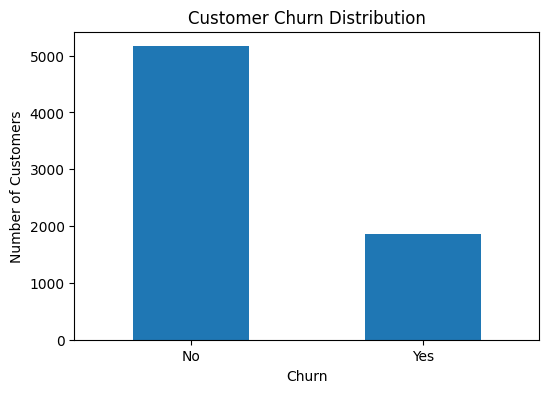

In [ ]:
# Churn count

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

df_clean["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Churn percentage

churn_percentage = (
    df_clean["Churn"]
    .value_counts(normalize=True) * 100
)

print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [ ]:
# Contract Vs Churn

contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


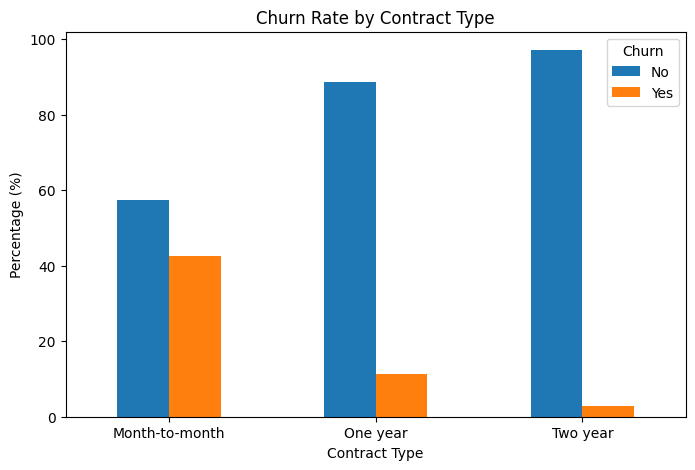

In [ ]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

<Figure size 800x500 with 0 Axes>

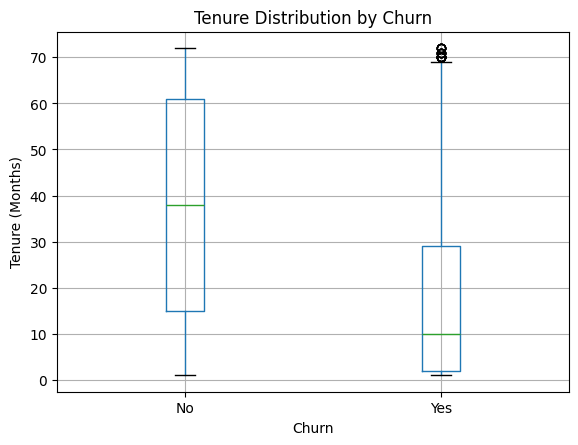

In [ ]:
# Tenure vs churn

plt.figure(figsize=(8, 5))

df_clean.boxplot(
    column="tenure",
    by="Churn"
)

plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

<Figure size 800x500 with 0 Axes>

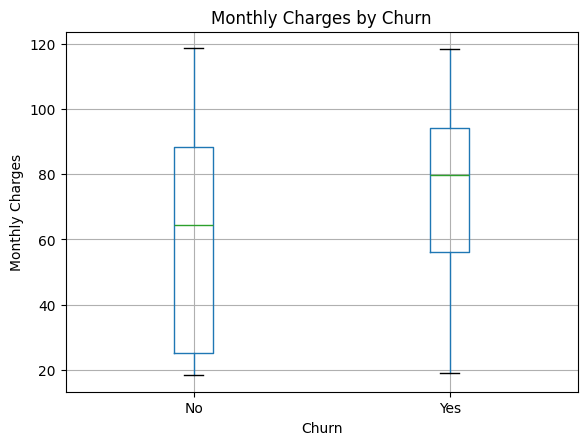

In [ ]:
# Monthly charges vs Churn

plt.figure(figsize=(8, 5))

df_clean.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [ ]:
# Payment method vs churn

payment_churn = pd.crosstab(
    df_clean["PaymentMethod"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


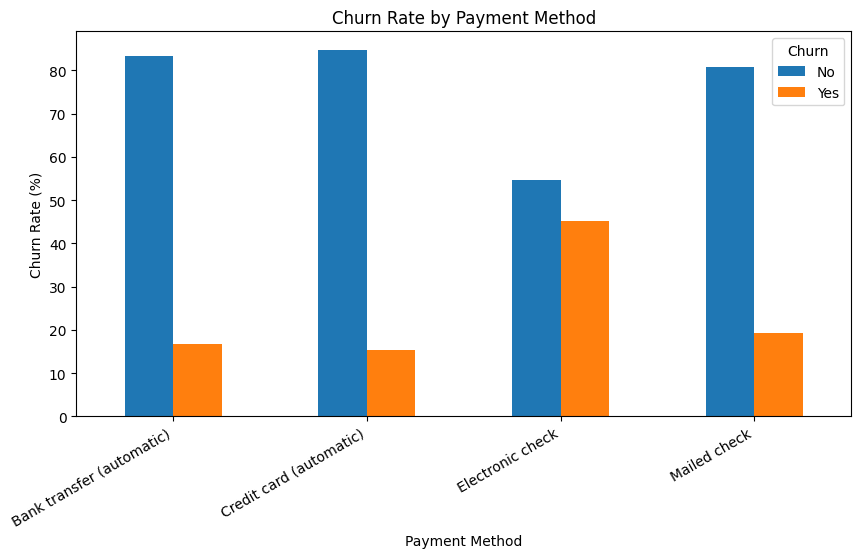

In [ ]:
payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Churn")

plt.show()

In [ ]:
# Internet service vs churn

internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211


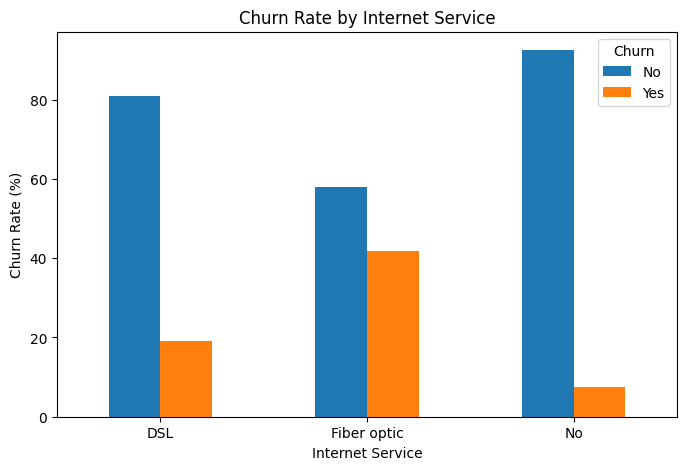

In [ ]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [ ]:
# Tenure groups

df_clean["tenure_group"] = pd.cut(
    df_clean["tenure"],
    bins=[0, 12, 24, 48, 60, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-60 months",
        "61-72 months"
    ],
    include_lowest=True
)

In [ ]:
tenure_churn = pd.crosstab(
    df_clean["tenure_group"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(tenure_churn)

Churn                No        Yes
tenure_group                      
0-12 months   52.321839  47.678161
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49-60 months  85.576923  14.423077
61-72 months  93.390192   6.609808


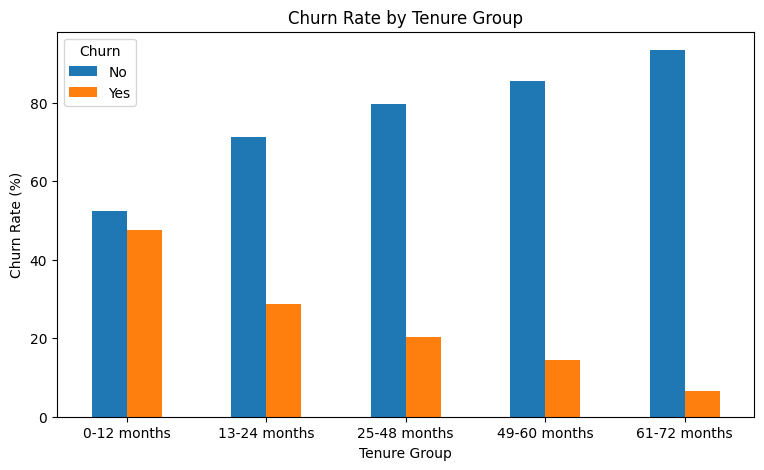

In [ ]:
tenure_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [ ]:
# Churn by Senior citizen

senior_churn = pd.crosstab(
    df_clean["SeniorCitizen"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(senior_churn)

Churn                 No        Yes
SeniorCitizen                      
0              76.349745  23.650255
1              58.318739  41.681261


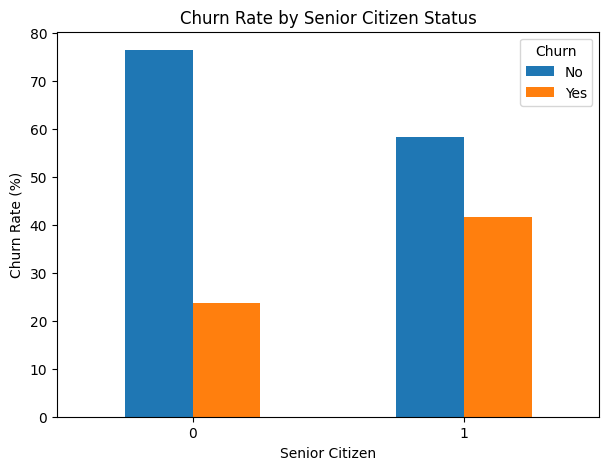

In [ ]:
senior_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [ ]:
# Calculate the important buisness statistics

print("Average Monthly Charges:")
print(
    df_clean.groupby("Churn")["MonthlyCharges"].mean()
)

print("\nAverage Tenure:")
print(
    df_clean.groupby("Churn")["tenure"].mean()
)

print("\nAverage Total Charges:")
print(
    df_clean.groupby("Churn")["TotalCharges"].mean()
)

Average Monthly Charges:
Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

Average Tenure:
Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

Average Total Charges:
Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64


Feature Engineering

In [ ]:
# Create total_services

service_columns = [
    "PhoneService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_clean["total_services"] = 0

for col in service_columns:
    df_clean["total_services"] += (
        df_clean[col].isin(["Yes", "Yes"])
    ).astype(int)

print(df_clean["total_services"].value_counts().sort_index())

total_services
0      80
1    2247
2     996
3    1041
4    1060
5     825
6     524
7     259
Name: count, dtype: int64


In [ ]:
df_clean["total_services"] = (
    df_clean[service_columns] == "Yes"
).sum(axis=1)

print(df_clean["total_services"].describe())

count    7032.000000
mean        2.941411
std         1.843695
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max         7.000000
Name: total_services, dtype: float64


In [ ]:
# Create is_high_value_customer

print(df_clean["MonthlyCharges"].describe())

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64


In [ ]:
high_value_threshold = df_clean["MonthlyCharges"].quantile(0.75)

df_clean["is_high_value_customer"] = (
    df_clean["MonthlyCharges"] >= high_value_threshold
).astype(int)

print("High-value threshold:", high_value_threshold)
print(
    df_clean["is_high_value_customer"].value_counts()
)

High-value threshold: 89.8625
is_high_value_customer
0    5274
1    1758
Name: count, dtype: int64


In [ ]:
# Create is_month_to_month

df_clean["is_month_to_month"] = (
    df_clean["Contract"] == "Month-to-month"
).astype(int)

print(
    df_clean["is_month_to_month"].value_counts()
)

is_month_to_month
1    3875
0    3157
Name: count, dtype: int64


In [ ]:
# Create has_partner_dependents

df_clean["has_partner_or_dependents"] = (
    (df_clean["Partner"] == "Yes") |
    (df_clean["Dependents"] == "Yes")
).astype(int)

print(
    df_clean["has_partner_or_dependents"].value_counts()
)

has_partner_or_dependents
1    3752
0    3280
Name: count, dtype: int64


In [ ]:
# Create avg_monthly_spend

df_clean["avg_monthly_spend"] = (
    df_clean["TotalCharges"] /
    df_clean["tenure"].replace(0, np.nan)
)

In [ ]:
print(df_clean["avg_monthly_spend"].describe())

count    7032.000000
mean       64.799424
std        30.185891
min        13.775000
25%        36.179891
50%        70.373239
75%        90.179560
max       121.400000
Name: avg_monthly_spend, dtype: float64


In [ ]:
print(
    "Missing avg_monthly_spend:",
    df_clean["avg_monthly_spend"].isnull().sum()
)

Missing avg_monthly_spend: 0


In [ ]:
# Check our new features
new_features = [
    "total_services",
    "is_high_value_customer",
    "is_month_to_month",
    "has_partner_or_dependents",
    "avg_monthly_spend"
]

df_clean[new_features].head()


,total_services,is_high_value_customer,is_month_to_month,has_partner_or_dependents,avg_monthly_spend
0,1,0,1,1,29.850000
1,3,0,0,0,55.573529
2,3,0,1,0,54.075000
3,3,0,0,0,40.905556
4,1,0,1,0,75.825000


In [ ]:
df_clean[new_features].describe()

,total_services,is_high_value_customer,is_month_to_month,has_partner_or_dependents,avg_monthly_spend
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,2.941411,0.250000,0.551052,0.533561,64.799424
std,1.843695,0.433043,0.497422,0.498908,30.185891
min,0.000000,0.000000,0.000000,0.000000,13.775000
25%,1.000000,0.000000,0.000000,0.000000,36.179891
50%,3.000000,0.000000,1.000000,1.000000,70.373239
75%,4.000000,0.250000,1.000000,1.000000,90.179560
max,7.000000,1.000000,1.000000,1.000000,121.400000


In [ ]:
# Total services vs churn
services_churn = pd.crosstab(
    df_clean["total_services"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(services_churn)

Churn                  No        Yes
total_services                      
0               56.250000  43.750000
1               78.282154  21.717846
2               56.526104  43.473896
3               65.321806  34.678194
4               72.735849  27.264151
5               77.939394  22.060606
6               87.404580  12.595420
7               94.208494   5.791506


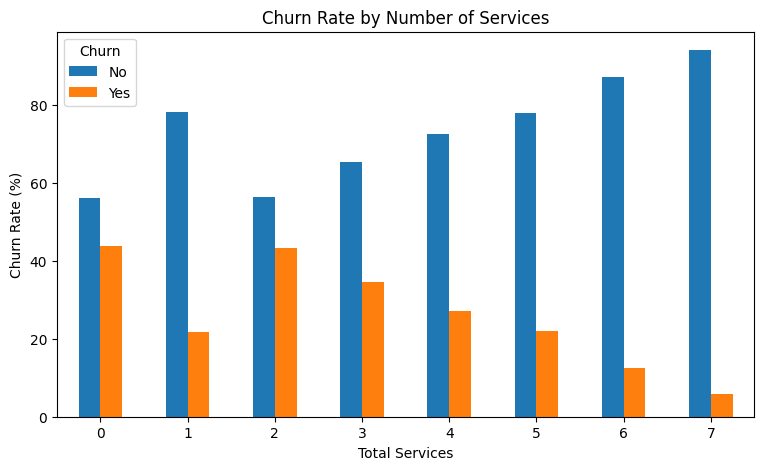

In [ ]:
services_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Number of Services")
plt.xlabel("Total Services")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [ ]:
# High value customer vs churn

high_value_churn = pd.crosstab(
    df_clean["is_high_value_customer"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(high_value_churn)

Churn                          No        Yes
is_high_value_customer                      
0                       75.521426  24.478574
1                       67.121729  32.878271


In [ ]:
# Month to month vs churn

monthly_contract_churn = pd.crosstab(
    df_clean["is_month_to_month"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(monthly_contract_churn)

Churn                     No        Yes
is_month_to_month                      
0                  93.221413   6.778587
1                  57.290323  42.709677


Prepare Target variable

In [ ]:
df_clean["Churn"] = df_clean["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df_clean["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


Remove tenure_group

In [ ]:
df_clean = df_clean.drop(
    "tenure_group",
    axis=1
)

print(df_clean.shape)

(7032, 25)


Prepare data for Machine Learning

In [ ]:
# Separate X and Y
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 24)
y shape: (7032,)


In [ ]:
# Identify numerical and categorical columns
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'total_services', 'is_high_value_customer', 'is_month_to_month', 'has_partner_or_dependents', 'avg_monthly_spend']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Train/test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 24)
Testing data: (1407, 24)


Check churn distribution

In [ ]:
print("Original:")
print(y.value_counts(normalize=True) * 100)

Original:
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [ ]:
print("\nTraining:")
print(y_train.value_counts(normalize=True) * 100)


Training:
Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64


In [ ]:
print("\nTesting:")
print(y_test.value_counts(normalize=True) * 100)


Testing:
Churn
0    73.418621
1    26.581379
Name: proportion, dtype: float64


Build Preprocessing Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

Fit preprocessing ONLY on training data

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

Training processed shape: (5625, 35)
Testing processed shape: (1407, 35)


First ML Model: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [ ]:
logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


Make Predictions

In [ ]:
y_pred = logistic_model.predict(X_test_processed)

y_probability = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

Evaluate the baseline Model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("Logistic Regression Results")
print("----------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Results
----------------------------
Accuracy : 0.8031
Precision: 0.6483
Recall   : 0.5668
F1 Score : 0.6049
ROC-AUC  : 0.8358


Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



Confusion Matrix

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[918 115]
 [162 212]]


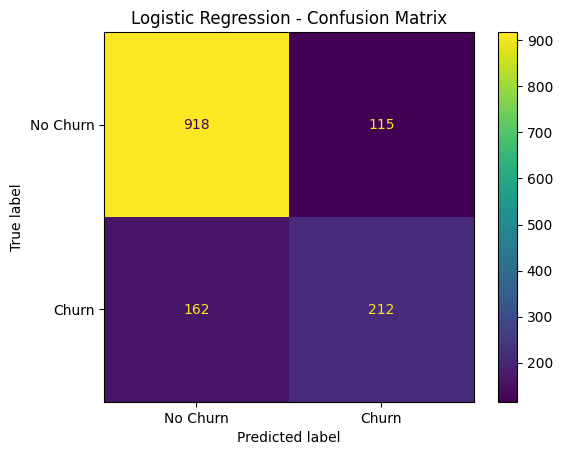

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Random forest

In [ ]:
#import random forest
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Create the model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Train the model
rf_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
# Make predictions
rf_pred = rf_model.predict(X_test_processed)

rf_probability = rf_model.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
# Evaluate random forest
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probability
)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Results
---------------------
Accuracy : 0.7434
Precision: 0.5113
Recall   : 0.7861
F1 Score : 0.6196
ROC-AUC  : 0.8362


In [ ]:
# Classification report
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407



In [ ]:
# Confusion Matrix
rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print(rf_cm)

[[752 281]
 [ 80 294]]


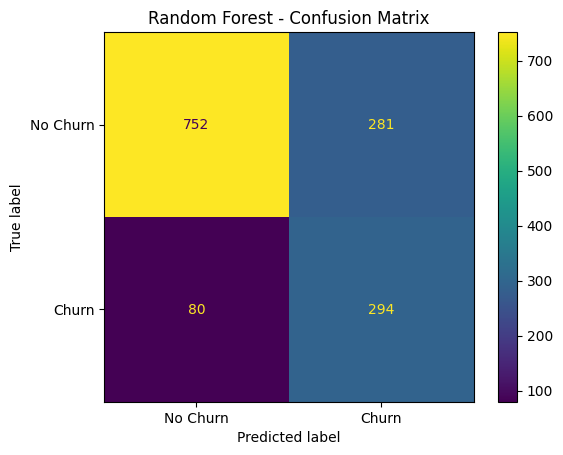

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

compare logistic regression vs random

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803127,0.648318,0.566845,0.60485,0.835771
1,Random Forest,0.743426,0.511304,0.786096,0.61960,0.836180


Visual Model Comparison

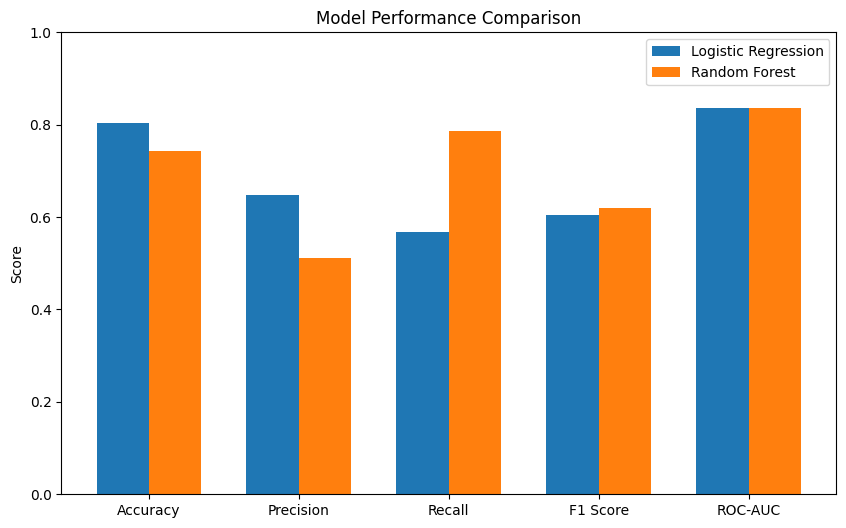

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    model_comparison.iloc[0][metrics],
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width/2,
    model_comparison.iloc[1][metrics],
    width,
    label="Random Forest"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.legend()

plt.show()

XGBoost

In [ ]:
!pip install xgboost -q

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb_model.fit(
    X_train_processed,
    y_train
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [ ]:
# Prediction
xgb_pred = xgb_model.predict(
    X_test_processed
)

xgb_probability = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
# Evaluation
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_probability
)

print("XGBoost Results")
print("----------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

XGBoost Results
----------------
Accuracy : 0.7839
Precision: 0.6115
Recall   : 0.5134
F1 Score : 0.5581
ROC-AUC  : 0.8292


In [ ]:
# Classification report
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.61      0.51      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



In [ ]:
# Confusion Matrix
xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

print(xgb_cm)

[[911 122]
 [182 192]]


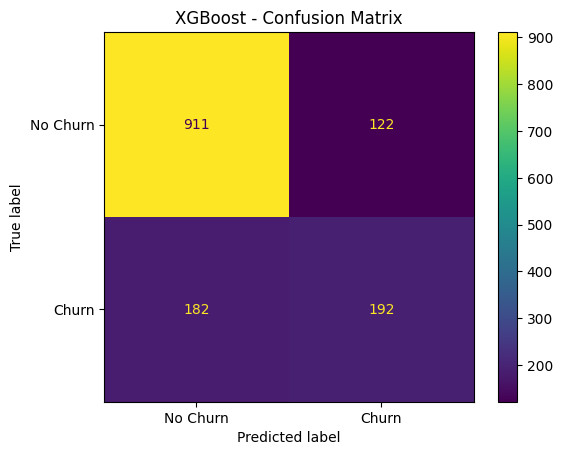

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("XGBoost - Confusion Matrix")
plt.show()

Create a proper model comparison

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803127,0.648318,0.566845,0.60485,0.835771
1,Random Forest,0.743426,0.511304,0.786096,0.61960,0.836180
2,XGBoost,0.783937,0.611465,0.513369,0.55814,0.829213


Visualize Model Performance

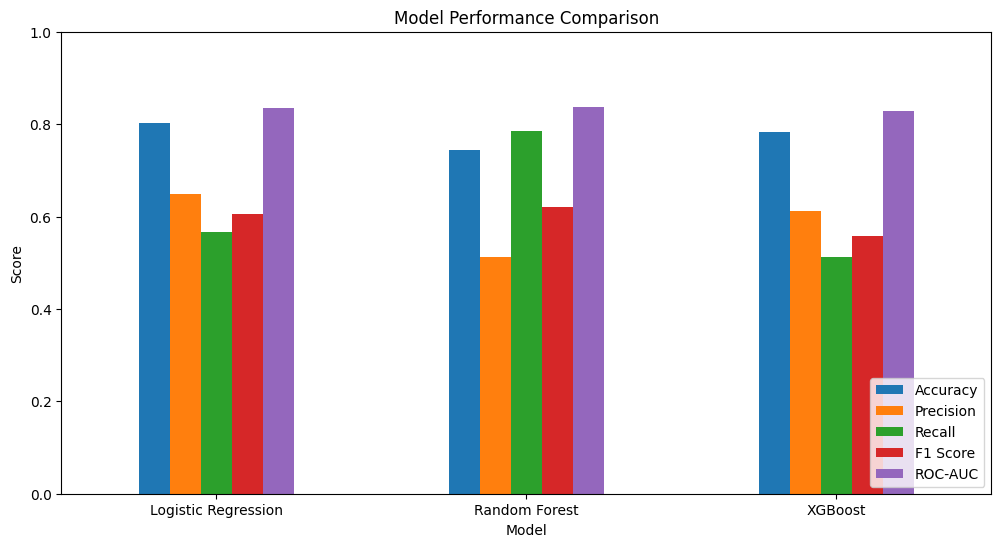

In [ ]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

model_comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

In [ ]:
X_train_new, X_valid, y_train_new, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train_new.shape)
print("Validation:", X_valid.shape)

Training: (4500, 24)
Validation: (1125, 24)


Preprocess the new training/validation sets

In [ ]:
preprocessor_tuning = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [ ]:
X_train_new_processed = (
    preprocessor_tuning.fit_transform(X_train_new)
)

X_valid_processed = (
    preprocessor_tuning.transform(X_valid)
)

In [ ]:
print(
    "Training processed:",
    X_train_new_processed.shape
)

print(
    "Validation processed:",
    X_valid_processed.shape
)

Training processed: (4500, 35)
Validation processed: (1125, 35)


Tune XGBoost

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_tune = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

grid = GridSearchCV(
    xgb_tune,
    param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_new_processed, y_train_new)

print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Best parameters: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV ROC-AUC: 0.8512314810320419


In [ ]:
best_xgb = grid.best_estimator_

valid_prob = best_xgb.predict_proba(X_valid_processed)[:, 1]
valid_pred = (valid_prob >= 0.5).astype(int)

print("Validation ROC-AUC:", roc_auc_score(y_valid, valid_prob))
print(classification_report(y_valid, valid_pred))

Validation ROC-AUC: 0.8378574262877875
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       826
           1       0.65      0.48      0.55       299

    accuracy                           0.79      1125
   macro avg       0.74      0.69      0.71      1125
weighted avg       0.78      0.79      0.78      1125



In [ ]:
#find best churn threshold
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_valid, valid_prob
)

f1_vals = 2 * (
    precision_vals[:-1] * recall_vals[:-1]
) / (
    precision_vals[:-1] + recall_vals[:-1] + 1e-9
)

best_idx = np.argmax(f1_vals)
best_threshold = thresholds[best_idx]

print("Best threshold:", round(best_threshold, 3))
print("Best validation F1:", round(f1_vals[best_idx], 4))

Best threshold: 0.349
Best validation F1: 0.6289


In [ ]:
# final  model on Test set
test_prob = best_xgb.predict_proba(X_test_processed)[:, 1]

test_pred = (
    test_prob >= best_threshold
).astype(int)

print("Final Model Results")
print("-------------------")
print("Accuracy :", round(accuracy_score(y_test, test_pred), 4))
print("Precision:", round(precision_score(y_test, test_pred), 4))
print("Recall   :", round(recall_score(y_test, test_pred), 4))
print("F1 Score :", round(f1_score(y_test, test_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, test_prob), 4))

Final Model Results
-------------------
Accuracy : 0.7385
Precision: 0.7143
Recall   : 0.0267
F1 Score : 0.0515
ROC-AUC  : 0.7623


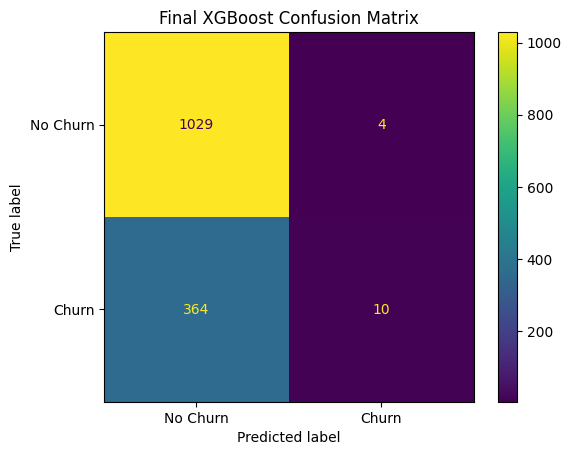

In [ ]:
cm = confusion_matrix(y_test, test_pred)

ConfusionMatrixDisplay(
    cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Final XGBoost Confusion Matrix")
plt.show()

SHAP Explainability

In [ ]:
!pip install shap -q

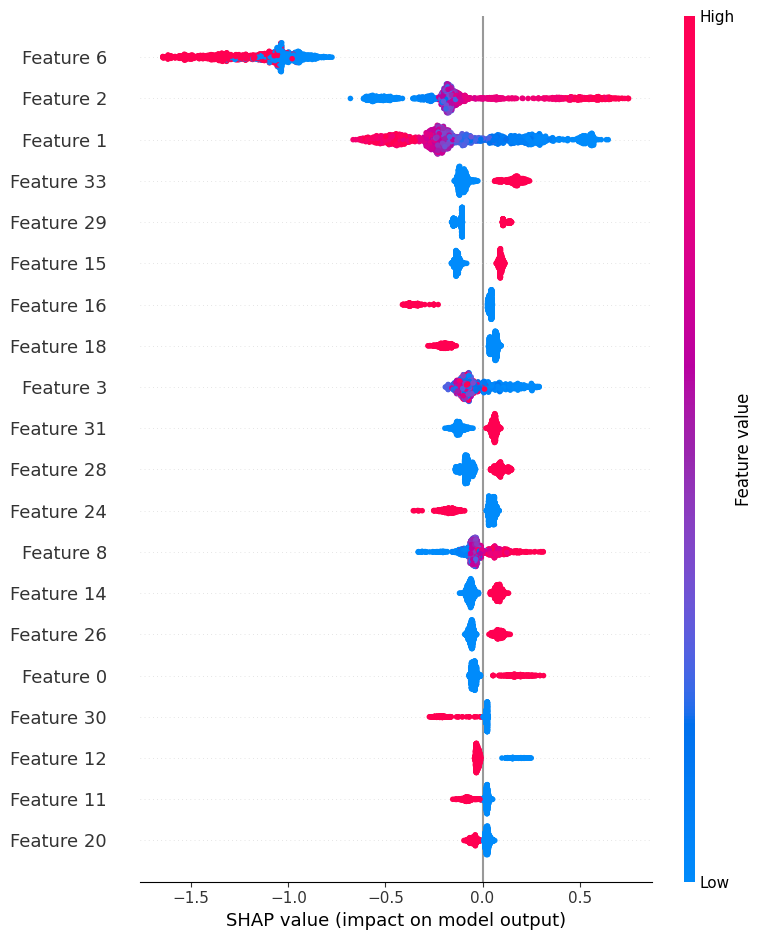

In [ ]:
import shap

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(
    shap_values,
    X_test_processed
)

Final model comparison

In [ ]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy,
        accuracy_score(y_test, test_pred)
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision,
        precision_score(y_test, test_pred)
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall,
        recall_score(y_test, test_pred)
    ],
    "F1": [
        f1,
        rf_f1,
        xgb_f1,
        f1_score(y_test, test_pred)
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc,
        roc_auc_score(y_test, test_prob)
    ]
})

final_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8031,0.6483,0.5668,0.6049,0.8358
1,Random Forest,0.7434,0.5113,0.7861,0.6196,0.8362
2,XGBoost,0.7839,0.6115,0.5134,0.5581,0.8292
3,Tuned XGBoost,0.7385,0.7143,0.0267,0.0515,0.7623


In [ ]:
# Final preprocessing on full training data

final_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"),
         categorical_features)
    ]
)

X_train_final = final_preprocessor.fit_transform(X_train)
X_test_final = final_preprocessor.transform(X_test)

# Final XGBoost

final_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(X_train_final, y_train)

print("Final XGBoost trained successfully!")

Final XGBoost trained successfully!


In [ ]:
test_prob = final_xgb.predict_proba(X_test_final)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

print("FINAL MODEL")
print("-----------")
print(f"Accuracy : {accuracy_score(y_test, test_pred):.4f}")
print(f"Precision: {precision_score(y_test, test_pred):.4f}")
print(f"Recall   : {recall_score(y_test, test_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, test_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, test_prob):.4f}")

FINAL MODEL
-----------
Accuracy : 0.7761
Precision: 0.5589
Recall   : 0.7487
F1 Score : 0.6400
ROC-AUC  : 0.8402


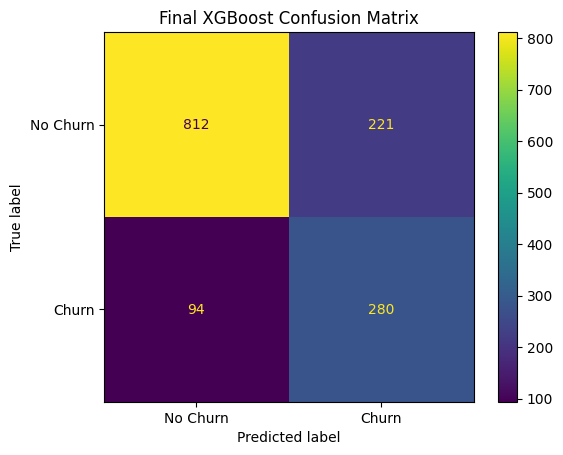

In [ ]:
cm = confusion_matrix(y_test, test_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Final XGBoost Confusion Matrix")
plt.show()

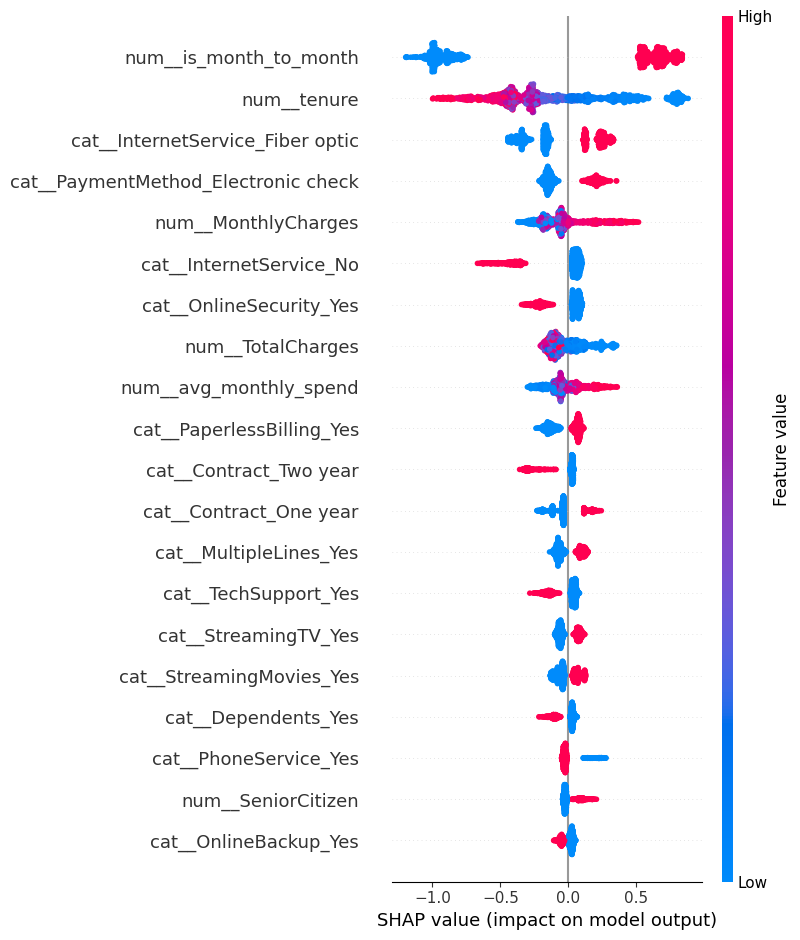

In [ ]:
import shap

feature_names = final_preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(final_xgb)

shap_values = explainer.shap_values(X_test_final)

shap.summary_plot(
    shap_values,
    X_test_final,
    feature_names=feature_names
)

f

In [ ]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy,
        accuracy_score(y_test, test_pred)
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision,
        precision_score(y_test, test_pred)
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall,
        recall_score(y_test, test_pred)
    ],
    "F1 Score": [
        f1,
        rf_f1,
        xgb_f1,
        f1_score(y_test, test_pred)
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc,
        roc_auc_score(y_test, test_prob)
    ]
})

final_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8031,0.6483,0.5668,0.6049,0.8358
1,Random Forest,0.7434,0.5113,0.7861,0.6196,0.8362
2,XGBoost,0.7839,0.6115,0.5134,0.5581,0.8292
3,Tuned XGBoost,0.7761,0.5589,0.7487,0.6400,0.8402


In [ ]:
final_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "Tuned XGBoost"],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy,
        accuracy_score(y_test, test_pred)
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision,
        precision_score(y_test, test_pred)
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall,
        recall_score(y_test, test_pred)
    ],
    "F1": [
        f1,
        rf_f1,
        xgb_f1,
        f1_score(y_test, test_pred)
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc,
        roc_auc_score(y_test, test_prob)
    ]
})

final_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8031,0.6483,0.5668,0.6049,0.8358
1,Random Forest,0.7434,0.5113,0.7861,0.6196,0.8362
2,XGBoost,0.7839,0.6115,0.5134,0.5581,0.8292
3,Tuned XGBoost,0.7761,0.5589,0.7487,0.6400,0.8402


In [ ]:
print("""
KEY BUSINESS INSIGHTS
---------------------
1. Month-to-month customers have substantially higher churn risk.
2. Customers with shorter tenure are more likely to churn.
3. Electronic-check customers show higher churn than automatic-payment customers.
4. Fiber-optic customers show higher churn than DSL customers in this dataset.
5. Higher monthly charges are associated with greater churn risk.

RECOMMENDATIONS
---------------
- Offer incentives to move month-to-month customers to annual contracts.
- Target new customers with early-retention campaigns.
- Investigate pricing/service issues affecting high-charge customers.
- Encourage automatic payment methods.
- Prioritize high-risk customers identified by the ML model.
""")


KEY BUSINESS INSIGHTS
---------------------
1. Month-to-month customers have substantially higher churn risk.
2. Customers with shorter tenure are more likely to churn.
3. Electronic-check customers show higher churn than automatic-payment customers.
4. Fiber-optic customers show higher churn than DSL customers in this dataset.
5. Higher monthly charges are associated with greater churn risk.

RECOMMENDATIONS
---------------
- Offer incentives to move month-to-month customers to annual contracts.
- Target new customers with early-retention campaigns.
- Investigate pricing/service issues affecting high-charge customers.
- Encourage automatic payment methods.
- Prioritize high-risk customers identified by the ML model.



In [ ]:
import joblib

joblib.dump(final_xgb, "customer_churn_xgboost.pkl")
joblib.dump(final_preprocessor, "churn_preprocessor.pkl")

print("Model and preprocessor saved!")

Model and preprocessor saved!


In [ ]:
final_comparison.round(4).to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved!")

Model comparison saved!


h

In [ ]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 47.6 MB/s eta 0:00:00


In [ ]:
import streamlit
print("Streamlit installed successfully!")

Streamlit installed successfully!


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

model = joblib.load("customer_churn_xgboost.pkl")
preprocessor = joblib.load("churn_preprocessor.pkl")

st.set_page_config(
    page_title="Customer Churn Prediction",
    page_icon="📊"
)

st.title("📊 Customer Churn Prediction")
st.write("Machine Learning powered customer churn risk prediction")

gender = st.selectbox("Gender", ["Male", "Female"])
senior = st.selectbox("Senior Citizen", [0, 1])
partner = st.selectbox("Partner", ["Yes", "No"])
dependents = st.selectbox("Dependents", ["Yes", "No"])

tenure = st.slider("Tenure (Months)", 0, 72, 12)

phone = st.selectbox("Phone Service", ["Yes", "No"])

multiple_lines = st.selectbox(
    "Multiple Lines",
    ["Yes", "No", "No phone service"]
)

internet = st.selectbox(
    "Internet Service",
    ["DSL", "Fiber optic", "No"]
)

security = st.selectbox(
    "Online Security",
    ["Yes", "No", "No internet service"]
)

backup = st.selectbox(
    "Online Backup",
    ["Yes", "No", "No internet service"]
)

device = st.selectbox(
    "Device Protection",
    ["Yes", "No", "No internet service"]
)

support = st.selectbox(
    "Tech Support",
    ["Yes", "No", "No internet service"]
)

tv = st.selectbox(
    "Streaming TV",
    ["Yes", "No", "No internet service"]
)

movies = st.selectbox(
    "Streaming Movies",
    ["Yes", "No", "No internet service"]
)

contract = st.selectbox(
    "Contract",
    ["Month-to-month", "One year", "Two year"]
)

paperless = st.selectbox(
    "Paperless Billing",
    ["Yes", "No"]
)

payment = st.selectbox(
    "Payment Method",
    [
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]
)

monthly_charges = st.number_input(
    "Monthly Charges",
    min_value=0.0,
    value=70.0
)

total_charges = st.number_input(
    "Total Charges",
    min_value=0.0,
    value=1000.0
)

if st.button("🔮 Predict Churn"):

    total_services = sum([
        phone == "Yes",
        security == "Yes",
        backup == "Yes",
        device == "Yes",
        support == "Yes",
        tv == "Yes",
        movies == "Yes"
    ])

    is_high_value = int(monthly_charges >= 89.8625)
    is_month_to_month = int(contract == "Month-to-month")
    has_partner_or_dependents = int(
        partner == "Yes" or dependents == "Yes"
    )

    avg_monthly_spend = (
        total_charges / tenure
        if tenure > 0
        else monthly_charges
    )

    input_data = pd.DataFrame({
        "gender": [gender],
        "SeniorCitizen": [senior],
        "Partner": [partner],
        "Dependents": [dependents],
        "tenure": [tenure],
        "PhoneService": [phone],
        "MultipleLines": [multiple_lines],
        "InternetService": [internet],
        "OnlineSecurity": [security],
        "OnlineBackup": [backup],
        "DeviceProtection": [device],
        "TechSupport": [support],
        "StreamingTV": [tv],
        "StreamingMovies": [movies],
        "Contract": [contract],
        "PaperlessBilling": [paperless],
        "PaymentMethod": [payment],
        "MonthlyCharges": [monthly_charges],
        "TotalCharges": [total_charges],
        "total_services": [total_services],
        "is_high_value_customer": [is_high_value],
        "is_month_to_month": [is_month_to_month],
        "has_partner_or_dependents": [has_partner_or_dependents],
        "avg_monthly_spend": [avg_monthly_spend]
    })

    processed = preprocessor.transform(input_data)

    probability = model.predict_proba(processed)[0][1]

    prediction = probability >= 0.349

    st.subheader("Prediction Result")

    st.metric(
        "Churn Probability",
        f"{probability:.1%}"
    )

    if prediction:
        st.error("🔴 HIGH CHURN RISK")
        st.warning(
            "Recommended Action: Contact the customer "
            "with a retention offer."
        )
    else:
        st.success("🟢 LOW CHURN RISK")
        st.info(
            "Recommended Action: Continue regular "
            "customer engagement."
        )

Writing app.py


In [ ]:
import os

print(os.path.exists("app.py"))

True


In [ ]:
import os

for file in [
    "app.py",
    "customer_churn_xgboost.pkl",
    "churn_preprocessor.pkl",
    "model_comparison.csv"
]:
    print(file, "✅" if os.path.exists(file) else "❌")

app.py ✅
customer_churn_xgboost.pkl ✅
churn_preprocessor.pkl ✅
model_comparison.csv ✅


In [ ]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
xgboost
joblib
shap

Writing requirements.txt


In [ ]:
print(open("requirements.txt").read())

streamlit
pandas
numpy
scikit-learn
xgboost
joblib
shap

